In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [4]:
df = pd.read_csv('C:/Users/nguye/SteamCrawler/Preprocessing/data.csv')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29906 entries, 0 to 29905
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Appid              29906 non-null  int64 
 1   Name               29906 non-null  object
 2   Type               29906 non-null  object
 3   ReleaseDate        29906 non-null  object
 4   Developers         29906 non-null  object
 5   Publishers         29906 non-null  object
 6   Description        29906 non-null  object
 7   price              29906 non-null  object
 8   Thumbnail          29906 non-null  object
 9   Tags               29906 non-null  object
 10  ReviewScore        29906 non-null  int64 
 11  PositiveReview     29906 non-null  int64 
 12  NegativeReview     29906 non-null  int64 
 13  OsRequirement      29906 non-null  object
 14  MemoryRequirement  29906 non-null  object
 15  CpuRequirement     29906 non-null  object
 16  Rank               29906 non-null  int64

In [6]:
df.isnull().sum() 

Appid                0
Name                 0
Type                 0
ReleaseDate          0
Developers           0
Publishers           0
Description          0
price                0
Thumbnail            0
Tags                 0
ReviewScore          0
PositiveReview       0
NegativeReview       0
OsRequirement        0
MemoryRequirement    0
CpuRequirement       0
Rank                 0
dtype: int64

In [7]:
df.isna().sum()

Appid                0
Name                 0
Type                 0
ReleaseDate          0
Developers           0
Publishers           0
Description          0
price                0
Thumbnail            0
Tags                 0
ReviewScore          0
PositiveReview       0
NegativeReview       0
OsRequirement        0
MemoryRequirement    0
CpuRequirement       0
Rank                 0
dtype: int64

In [8]:
#xử lí dữ liệu price, đây đang là object, cần chuyển về float 
df['price'] = df['price'].str.replace('$', '').astype(float)

In [9]:
display(df['OsRequirement'].value_counts())

OsRequirement
Windows 10                                3349
No requirement                            2923
Windows 7                                 2303
Windows 10 64-bit                          626
Windows XP                                 514
                                          ... 
32 bits                                      1
Windows 10 [64-bit]                          1
Windows® 10 Home 64 Bit (version 21H1)       1
XP XP                                        1
Windows 10 64-bit (1903+) / Windows 11       1
Name: count, Length: 4027, dtype: int64

In [10]:
#có tới 4027 giá trị khác nhau, nên sẽ rất khó để mã hóa, ta sẽ chia Os thành 5 nhóm chính 
def extract_os(x):
    x = str(x).lower()
    if 'no requirement' in x:
        return ['no requirement']
    os_list = []
    if 'windows' in x or 'win' in x:
        os_list.append('windows')
    if 'mac' in x or 'os x' in x:
        os_list.append('mac')
    if 'linux' in x or 'ubuntu' in x:
        os_list.append('linux')
    if not os_list:
        os_list.append('unknown')   
    return os_list
df['OsNew'] = df['OsRequirement'].apply(extract_os)

In [11]:
display(df['OsNew'].value_counts())

OsNew
[windows]                26190
[no requirement]          2923
[unknown]                  774
[windows, mac]              15
[windows, linux]             2
[windows, mac, linux]        1
[mac]                        1
Name: count, dtype: int64

In [12]:
df[df['OsNew'].apply(lambda x: 'unknown' in x)]['OsRequirement'].value_counts().head(20)

OsRequirement
10                                                  128
7                                                    71
Requires a 64-bit processor and operating system     48
XP                                                   42
7 / 8 / 8.1 / 10                                     33
Any                                                  26
Vista                                                15
XP, Vista, 7, 8, 10                                  12
7/8.1/10                                             12
7+                                                    9
7,8,10,11                                             9
XP, Vista, 7, 8                                       8
XP/Vista/7/8/10                                       8
7/8/10                                                7
7 / 8 / 10                                            7
Vista, 7, 8, 10                                       6
10+                                                   6
8                                 

In [13]:
#có thể thấy các giá trị này do viết quá tắt gây ra, nhưng có thể chia thành các nhóm 
# với any tương đương 'no requirement'
# Với requires a 64-bit processor, có thể coi là 'no requirement' vì đa số máy hiện nay đều có bộ xử lý 64-bit, nên ta sẽ gán nó vào nhóm 'no requirement'
# Với các máy còn lại thì có thể gán vào nhóm 'windows' vì đa số các máy này đều chạy windows, vì vista, xp, 7, 8, 10, 11 đều là hệ điều hành windows
# còn 1 trường hợp đặc biệt là có thể sử dụng trên 3 hdh chính là win, mac, linux thì cũng sẽ tương đương với 'no requirement' 
df['OsNew'] = df['OsNew'].apply(lambda x: ['no requirement'] if 'any' in x or 'requires a 64-bit processor' in x else (['windows'] if 'unknown' in x else x))
df['OsNew'] = df['OsNew'].apply(lambda x: ['no requirement'] if 'windows' in x and 'mac' in x and 'linux' in x else x)

In [14]:
display(df['OsNew'].value_counts())

OsNew
[windows]           26964
[no requirement]     2924
[windows, mac]         15
[windows, linux]        2
[mac]                   1
Name: count, dtype: int64

In [15]:
# Bây giờ ta đã tạo ra nhóm dễ xử lí hơn với 5 nhóm chính, giờ ta sẽ thay vào cột os requirement để tiện cho việc mã hóa sau này
df['OsRequirement'] = df['OsNew']
df.drop(columns=['OsNew'], inplace=True)

In [16]:
display(df['OsRequirement'].value_counts())

OsRequirement
[windows]           26964
[no requirement]     2924
[windows, mac]         15
[windows, linux]        2
[mac]                   1
Name: count, dtype: int64

In [17]:
# Tiếp tục là xử lí về ram .
display(df['MemoryRequirement'].value_counts())

MemoryRequirement
4 GB RAM                                                     7427
8 GB RAM                                                     5867
2 GB RAM                                                     4303
No requirement                                               3970
1 GB RAM                                                     2334
                                                             ... 
1GB (XP), 2GB (Vista), 2GB (Windows 7) GB RAM                   1
69 MB RAM                                                       1
8128 MB RAM                                                     1
512Mb RAM for Windows XP (1GB for Windows Vista & 7/8/10)       1
4GB of RAM                                                      1
Name: count, Length: 400, dtype: int64

In [18]:
def normalize_memory2(mem):
    if pd.isna(mem):
        return np.nan
    mem = mem.lower()
    nums = re.findall(r'\d+', mem)
    values = []
    for num in nums:
        if 'gb' or 'gigs' in mem:
            values.append(float(num) * 1024)
        elif 'mb' or 'm' in mem:
            values.append(float(num))
    return max(values) if values else 0 
df['NewMemoryRequirement'] = df['MemoryRequirement'].apply(normalize_memory2)
    

In [19]:
display(df['NewMemoryRequirement'].value_counts())

NewMemoryRequirement
4096.0       7643
8192.0       5980
2048.0       4476
0.0          3976
1024.0       2439
             ... 
358400.0        1
368640.0        1
6963200.0       1
1263616.0       1
593920.0        1
Name: count, Length: 98, dtype: int64

In [20]:
#Vậy ta đã biến feature này về dạng có quy tắc hơn rồi, sau quá trình kiểm tra cũng mang tính hợp lệ nên ta sẽ thay vào cột chính luôn 
df['MemoryRequirement'] = df['NewMemoryRequirement']
df.drop(columns=['NewMemoryRequirement'], inplace=True)

In [21]:
display(df['CpuRequirement'].value_counts())

CpuRequirement
No requirement               3844
Intel Core i5                 322
Intel Core i3                 272
Intel Core2 Duo or better     266
2 GHz                         232
                             ... 
2.5 Ghz 64-bit                  1
intel Core i Series             1
i5 4690 @ 3,5 Ghz               1
2GHz以上                          1
A couple                        1
Name: count, Length: 8427, dtype: int64

In [22]:
#có thể thấy có rất nhiều giá trị khác nhau về yêu cầu của game và cpu, nhưng ta có thể thấy rằng vẫn có các nhóm từ khóa xuất hiện, nên ta sẽ chia thành 3 nhóm yêu cầu chính là cpu_tier, CPU_Ghz, Cpu_requirement
import re
import numpy as np
import pandas as pd

def extract_cpu_info(x):
    x = str(x).lower()
    x = x.replace(',', '.')
    
    cpu_tier = 0
    cpu_ghz = np.nan
    cpu_requirement = 1
    
    # Với trường hợp không yêu cầu về cpu 
    if 'no requirement' in x:
        cpu_requirement = 0
        cpu_ghz = 0 
        cpu_tier = 0
        return pd.Series([cpu_requirement, cpu_ghz, cpu_tier])
    
    # tách thông tin về GHz nếu có
    ghz_match = re.search(r'(\d+(\.\d+)?)\s*ghz', x)
    if ghz_match:
        cpu_ghz = float(ghz_match.group(1))

    # chia cấp bậc cho các loại cpu dựa trên từ khóa xuất hiện
    tiers = []
    if any(k in x for k in ['i3', 'ryzen 3']):
        tiers.append(1)
    if any(k in x for k in ['i5', 'ryzen 5']):
        tiers.append(2)
    if any(k in x for k in ['i7', 'ryzen 7']):
        tiers.append(3)
    if any(k in x for k in ['i9', 'ryzen 9']):
        tiers.append(4) 
    if any(k in x for k in ['core2', 'duo', 'pentium', 'dual core', 'celeron']):
        tiers.append(1)
    if any(k in x for k in ['any', 'almost any', 'multi-core']):
        tiers.append(1)
    if 'last' in x and 'year' in x:
        tiers.append(2)
    if len(tiers) > 0:
        cpu_tier = min(tiers)
    else:
        cpu_tier = 0
    
    return pd.Series([cpu_requirement, cpu_ghz, cpu_tier])

In [23]:
df[['CPU_req', 'CPU_GHz', 'CPU_tier']] = df['CpuRequirement'].apply(extract_cpu_info)


In [24]:
display(df['CPU_req'].value_counts())
display(df['CPU_GHz'].value_counts())
display(df['CPU_tier'].value_counts())

CPU_req
1.0    26061
0.0     3845
Name: count, dtype: int64

CPU_GHz
0.00    3846
2.00    3295
2.40     946
1.00     847
3.00     831
        ... 
6.00       1
0.50       1
1.85       1
3.07       1
0.80       1
Name: count, Length: 71, dtype: int64

CPU_tier
1.0    12115
0.0    11160
2.0     6128
3.0      500
4.0        3
Name: count, dtype: int64

In [25]:
display(df['CPU_GHz'].value_counts())

CPU_GHz
0.00    3846
2.00    3295
2.40     946
1.00     847
3.00     831
        ... 
6.00       1
0.50       1
1.85       1
3.07       1
0.80       1
Name: count, Length: 71, dtype: int64

In [26]:
df.isnull().sum()

Appid                    0
Name                     0
Type                     0
ReleaseDate              0
Developers               0
Publishers               0
Description              0
price                    0
Thumbnail                0
Tags                     0
ReviewScore              0
PositiveReview           0
NegativeReview           0
OsRequirement            0
MemoryRequirement        0
CpuRequirement           0
Rank                     0
CPU_req                  0
CPU_GHz              14053
CPU_tier                 0
dtype: int64

In [27]:
#Với thành phần GHz có rất nhiều giá trị nan, là do trong feature yêu cầu về cpu có rất nhiều cách viết và đa số thì không sở hữu thông tin về GHz, vậy giờ với những dữ liệu nan, ta sẽ lấy giá trị median của các giá trị GHz đã có để thay thế, vì median sẽ không bị ảnh hưởng bởi các giá trị ngoại lai, và cũng sẽ phản ánh được xu hướng trung tâm của dữ liệu hơn là mean
med_ghz = df.groupby('CPU_tier')['CPU_GHz'].median()
def fill_ghz(row):
    if pd.isna(row['CPU_GHz']):
        return med_ghz[row['CPU_tier']]
    return row['CPU_GHz']
df['CPU_GHz'] = df.apply(fill_ghz, axis=1)

In [28]:
df.isnull().sum()

Appid                0
Name                 0
Type                 0
ReleaseDate          0
Developers           0
Publishers           0
Description          0
price                0
Thumbnail            0
Tags                 0
ReviewScore          0
PositiveReview       0
NegativeReview       0
OsRequirement        0
MemoryRequirement    0
CpuRequirement       0
Rank                 0
CPU_req              0
CPU_GHz              0
CPU_tier             0
dtype: int64

In [29]:
#Sau khi tách xong ta chỉ cần bỏ cột CpuRequirement
df.drop(columns=['CpuRequirement'], inplace=True)

In [30]:
df['Tags']

0                                         Action,Adventure
1        FPS,Shooter,Multiplayer,Competitive,Action,Tea...
2        Extraction Shooter,Multiplayer,PvP,PvE,Third-P...
3                                      Action,Free To Play
4        Free to Play,Multiplayer,Battle Royale,FPS,Sho...
                               ...                        
29901    Indie,Adventure,RPGMaker,Female Protagonist,Si...
29902    LGBTQ+,Female Protagonist,JRPG,Indie,Story Ric...
29903                            Action,Free to Play,Indie
29904    Singleplayer,RPG,2D,Fantasy,Pixel Graphics,Sto...
29905    Precision Platformer,Difficult,2D Platformer,S...
Name: Tags, Length: 29906, dtype: object

In [31]:
df['Tag_list'] = df['Tags'].apply(lambda x: x.split(',') if pd.notna(x) else [])
df['Tag_list']

0                                      [Action, Adventure]
1        [FPS, Shooter, Multiplayer, Competitive, Actio...
2        [Extraction Shooter, Multiplayer, PvP, PvE, Th...
3                                   [Action, Free To Play]
4        [Free to Play, Multiplayer, Battle Royale, FPS...
                               ...                        
29901    [Indie, Adventure, RPGMaker, Female Protagonis...
29902    [LGBTQ+, Female Protagonist, JRPG, Indie, Stor...
29903                        [Action, Free to Play, Indie]
29904    [Singleplayer, RPG, 2D, Fantasy, Pixel Graphic...
29905    [Precision Platformer, Difficult, 2D Platforme...
Name: Tag_list, Length: 29906, dtype: object

In [32]:
value_counts = df['Tag_list'].explode().value_counts()  
display(value_counts.head(20))

Tag_list
Singleplayer      16914
Indie             13166
Action            12356
Adventure         12105
Casual             9599
Simulation         8668
2D                 8181
Strategy           7086
RPG                6587
Atmospheric        6490
Story Rich         5942
3D                 5281
Multiplayer        5175
Exploration        5090
Cute               5022
Puzzle             4805
Colorful           4552
Pixel Graphics     4438
First-Person       4385
Funny              4067
Name: count, dtype: int64

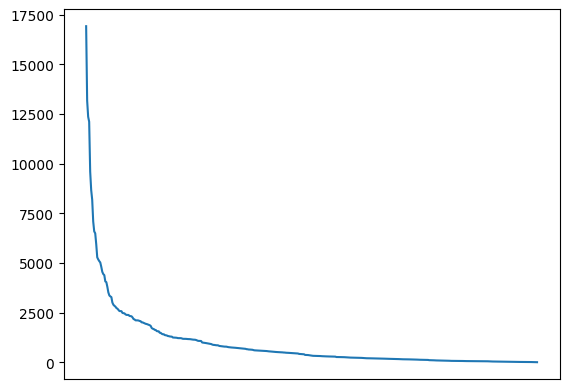

In [33]:
plt.plot(value_counts)
plt.xticks([])
plt.show()


In [34]:
#Dựa vào biểu đồ và số liệu, ta có thể thấy rằng có một số tag xuất hiện rất nhiều lần, nhưng cũng có rất nhiều tag chỉ xuất hiện 1 lần, ta sẽ kiểm tra ma trận đồng xuất hiện để xét tính đồng xuất hiện của các tag
tags = df['Tag_list'].explode().unique()
matrix = pd.DataFrame(0, index=tags, columns=tags)
for tag_list in df['Tag_list']:
    for i in range(len(tag_list)):
        for j in range(i + 1, len(tag_list)):
            matrix.loc[tag_list[i], tag_list[j]] += 1
            matrix.loc[tag_list[j], tag_list[i]] += 1

KeyboardInterrupt: 

In [ ]:
sorted_matrix = matrix.stack().sort_values(ascending=False)
sorted_matrix.head(20)

Singleplayer  Indie           9038
Indie         Singleplayer    9038
Singleplayer  Adventure       7932
Adventure     Singleplayer    7932
Action        Singleplayer    6807
Singleplayer  Action          6807
Casual        Singleplayer    6506
Singleplayer  Casual          6506
2D            Singleplayer    6392
Singleplayer  2D              6392
Indie         Adventure       5964
Adventure     Indie           5964
              Action          5722
Action        Adventure       5722
Indie         Casual          5568
Casual        Indie           5568
Action        Indie           5317
Indie         Action          5317
Simulation    Singleplayer    5149
Singleplayer  Simulation      5149
dtype: int64

In [42]:
print(list(value_counts.item()))

ValueError: can only convert an array of size 1 to a Python scalar